In [1]:
import os,sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from plotnine import *
import re
import glob

In [2]:
path_process = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster'
exclude = ['plots', 'qc_stats', 'qc_stats_welch']
folders = sorted([
    f for f in os.listdir(path_process) 
    if os.path.isdir(os.path.join(path_process, f)) 
    and not f.startswith('.') 
    and f not in exclude
])

In [3]:
df_rest = []
df_stim = []
for folder in folders:
    pattern = glob.glob(os.path.join(path_process, folder, 'guide_assigned.csv'))[0]
    df_cell = pd.read_csv(pattern)
    df_cell['sample_name'] = folder
    if 'Rest' in folder:
        df_rest.append(df_cell)
    if 'Stim' in folder:
        df_stim.append(df_cell)

In [4]:
df_cell_rest = pd.concat(df_rest, axis = 0)
df_cell_stim = pd.concat(df_stim, axis= 0)

In [5]:
# Rest
df_guide_rest = pd.DataFrame(df_cell_rest.groupby('cell').size(), columns=['number_of_guides'])
df_guide_rest['donor'] = df_guide_rest.index.str.split('_').str[2]
df_guide_rest['construct'] = df_guide_rest.index.str.split('_').str[3]
df_guide_rest['condition'] = df_guide_rest.index.str.split('_').str[4]
# Stim
df_guide_stim = pd.DataFrame(df_cell_stim.groupby('cell').size(), columns=['number_of_guides'])
df_guide_stim['donor'] = df_guide_stim.index.str.split('_').str[2]
df_guide_stim['construct'] = df_guide_stim.index.str.split('_').str[3]
df_guide_stim['condition'] = df_guide_stim.index.str.split('_').str[4]
df_guide_stim.head()

,number_of_guides,donor,construct,condition
cell,,,,
AAACAAGCAAACAAGAAACGCCGA-1_lane1_D1_408i_Stim,2,D1,408i,Stim
AAACAAGCAAACCGGTAACGCCGA-1_lane6_D1_408i_Stim,2,D1,408i,Stim
AAACAAGCAAACCGGTACTACTCA-1_lane6_D2_407a_Stim,1,D2,407a,Stim
AAACAAGCAAACCGTAACAGTCTG-1_lane2_D1_400a_Stim,2,D1,400a,Stim
AAACAAGCAAACCGTAATTCGGTT-1_lane2_D2_408i_Stim,1,D2,408i,Stim


In [7]:
df_guide =  pd.concat([df_guide_rest, df_guide_stim], axis=0)

In [ ]:
plt_path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/plots'

### Number of Guide assigned per cell by condition

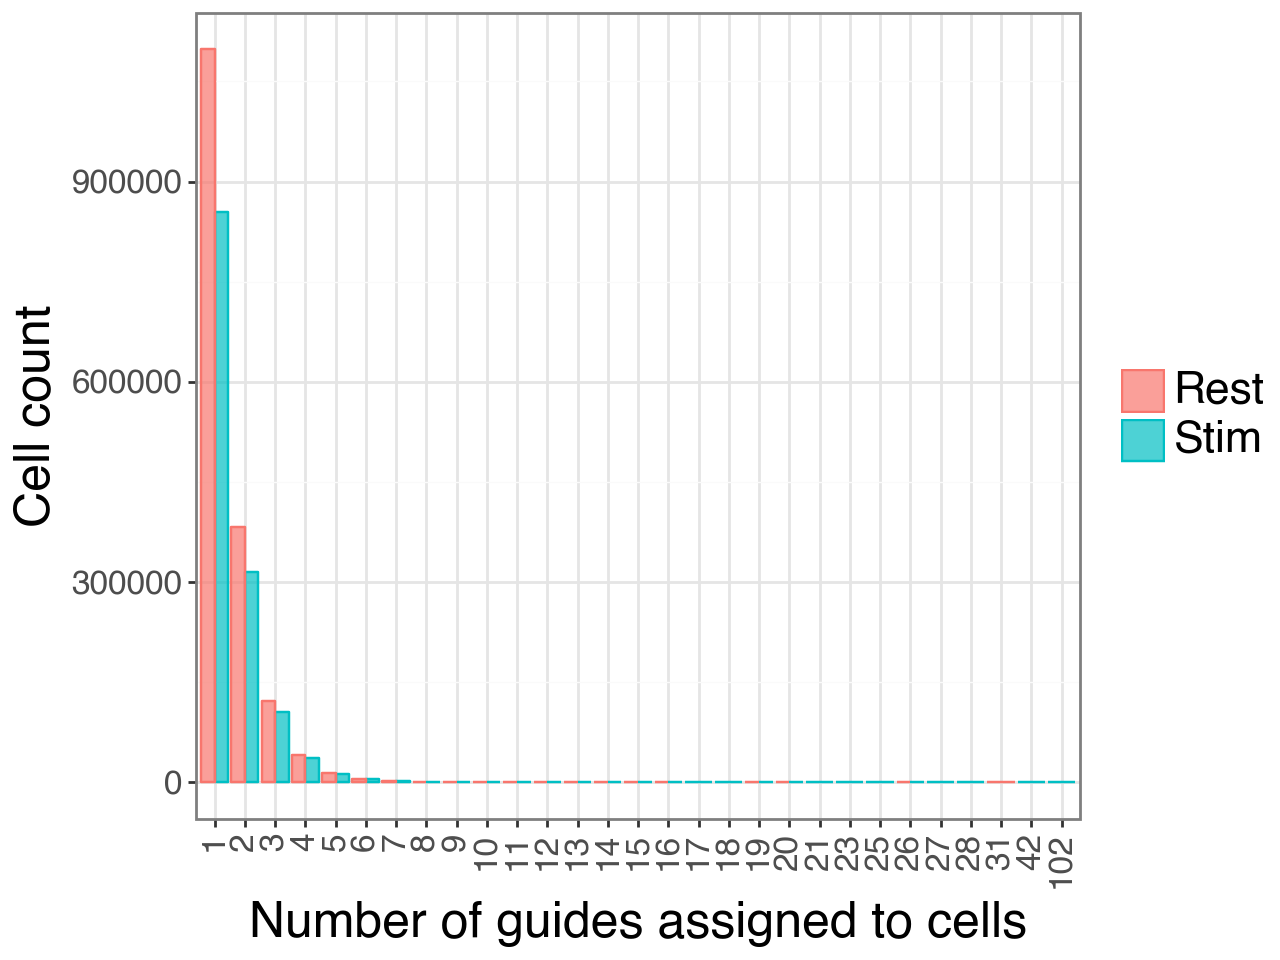

In [8]:
p = (
    ggplot(df_guide, aes(x='factor(number_of_guides)', fill='condition')) 
    + geom_bar(aes(color='condition'), alpha=0.7, position='dodge')
    + labs(x='Number of guides assigned to cells', 
           y='Cell count')
    + theme_bw()
    + theme(legend_title=element_blank(),
           legend_text = element_text(size = 16))
    +theme(
            plot_title = element_text(size = 16, face = "bold"),
            axis_title_x = element_text(size = 18),
            axis_title_y = element_text(size = 18),
            axis_text_x = element_text(size = 12,angle = 90), # Size of tick labels
            axis_text_y = element_text(size = 12)  # Size of tick labels
              )
)
# p.save(os.path.join(plt_path, 'guides_count_per_cell.png'), dpi= 150)
p.show()


### Number of Guide assigned per cell by construct

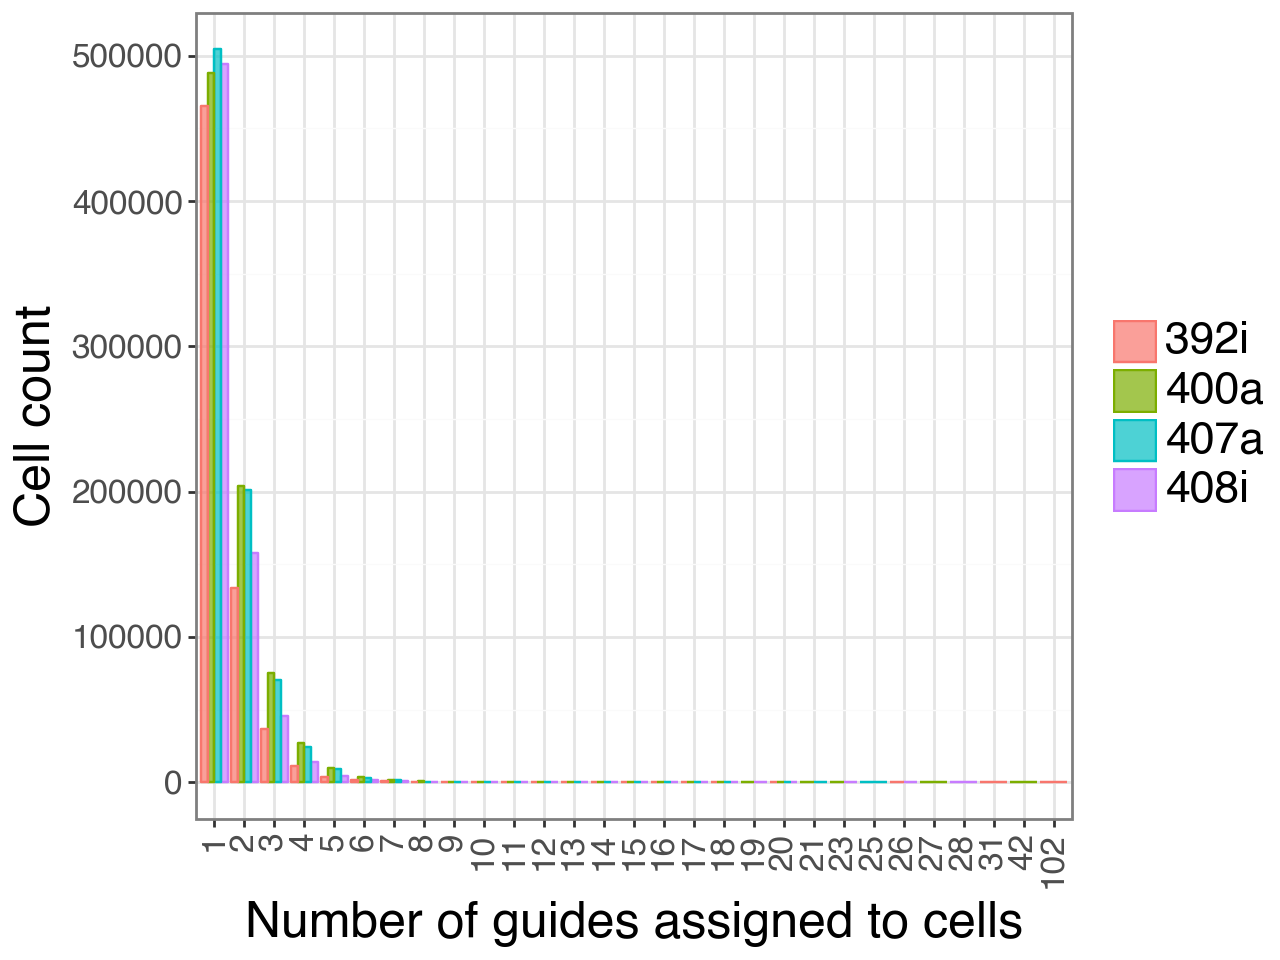

In [9]:
p = (
    ggplot(df_guide, aes(x='factor(number_of_guides)', fill='construct')) 
    + geom_bar(aes(color='construct'), alpha=0.7, position='dodge')
    + labs(x='Number of guides assigned to cells', 
           y='Cell count')
    + theme_bw()
    + theme(legend_title=element_blank(),
           legend_text = element_text(size = 16))
    +theme(
            plot_title = element_text(size = 16, face = "bold"),
            axis_title_x = element_text(size = 18),
            axis_title_y = element_text(size = 18),
            axis_text_x = element_text(size = 12,angle = 90), # Size of tick labels
            axis_text_y = element_text(size = 12)  # Size of tick labels
              )
)
# p.save(os.path.join(plt_path, 'guides_count_per_cell.png'), dpi= 150)
p.show()

### Number of Guide assigned per cell by donor

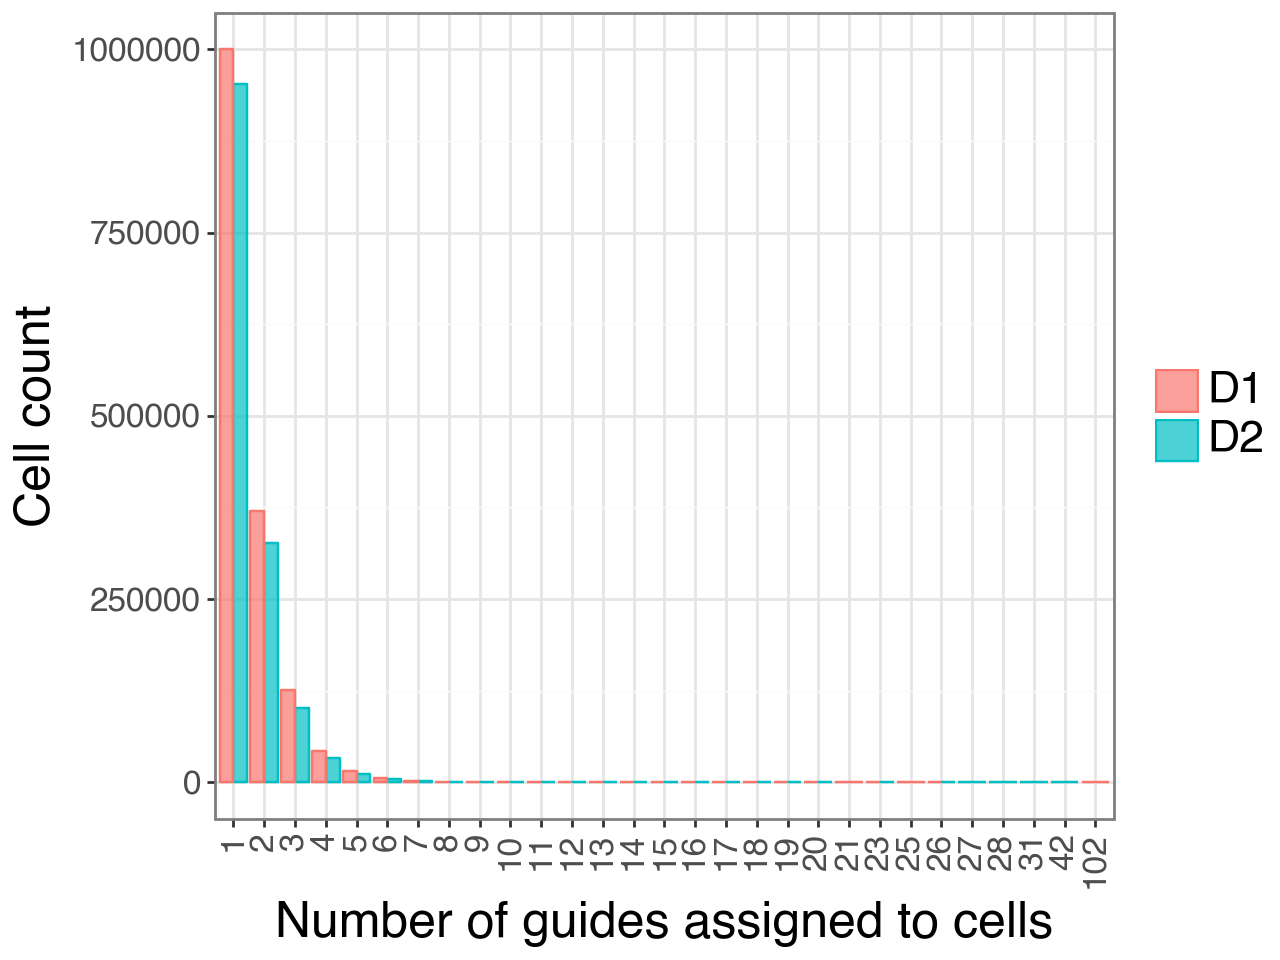

In [10]:
p = (
    ggplot(df_guide, aes(x='factor(number_of_guides)', fill='donor')) 
    + geom_bar(aes(color='donor'), alpha=0.7, position='dodge')
    + labs(x='Number of guides assigned to cells', 
           y='Cell count')
    + theme_bw()
    + theme(legend_title=element_blank(),
           legend_text = element_text(size = 16))
    +theme(
            plot_title = element_text(size = 16, face = "bold"),
            axis_title_x = element_text(size = 18),
            axis_title_y = element_text(size = 18),
            axis_text_x = element_text(size = 12,angle = 90), # Size of tick labels
            axis_text_y = element_text(size = 12)  # Size of tick labels
              )
)
# p.save(os.path.join(plt_path, 'guides_count_per_cell.png'), dpi= 150)
p.show()